In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.integrate import odeint, solve_ivp
from scipy.interpolate import CubicSpline
from sklearn.metrics import r2_score

import pickle
import random

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# Ground Truth Model

In [2]:
def case_study1(t, y, Ki):
    Ca, Cb, Cc = y
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    v1max = 4.5
    v2max = 2.5
    
    Km1 = 5
    Km2 = 5
    
    Ki1 = Ki[0]
    Ki2 = Ki[1]
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    inh1 = (1 + (Cc/Ki1))
    inh2 = (1 + (Cc/Ki2))
    
#     # Uncompetitive Inhibition    
#     v1 = ((v1max/inh1)*Ca)/((Ca + Km1*inh1))
#     v2 = ((v2max/inh2)*Cb)/((Ca + Km2*inh2))
    
    # Noncompetitive Inhibition    
    v1 = (v1max*Ca)/((Ca + Km1)*inh1)
    v2 = (v2max*Cb)/((Cb + Km2)*inh2)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    dCadt = -v1
    dCbdt = v1 - v2
    dCcdt = v2
    
    return [dCadt, dCbdt, dCcdt]

In [3]:
ICs = np.array([[0.5, 0, 0],
                [0.2, 0, 0]])

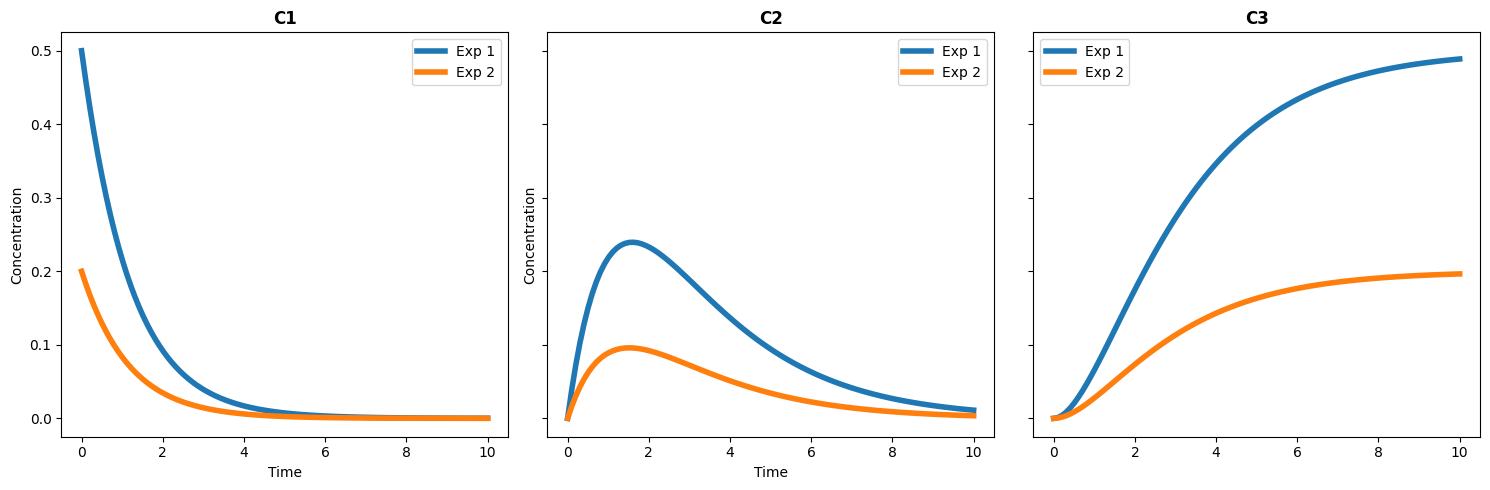

In [4]:
fig, axs = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
ax = axs.ravel()

for i in range(len(ICs)):
    ic = ICs[i]
    tspan = (0, 10)
    Ki = tuple([[5,5]])
    
    sol = solve_ivp(case_study1, 
                    tspan, 
                    ic,
                    args = Ki,
                    t_eval = np.linspace(tspan[0], tspan[-1], 100),
                    method = "Radau")
    
    y_fin = sol.y
    t_fin = sol.t
    
    for j in range(len(y_fin)):
        ax[j].plot(t_fin, y_fin[j], linewidth = 4, label = "Exp "+str(i+1))
        ax[j].legend()
        ax[j].set_title("C"+str(j+1), fontweight = "bold")
        
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel("Concentration")
    
    
    
plt.tight_layout()

# Generate Synthetic Raman Data

### Generate synthetic concentration data

In [5]:
def syn_GT_no_noise(num_time_steps = 10, Ki = Ki):
    
    ICs = np.array([[0.5, 0, 0],
                    [0.2, 0, 0]])
    
    final_dict = {}
    
    for i in range(len(ICs)):
        
        ic = ICs[i]
        tspan = (0, 20)
        
        teval = np.linspace(tspan[0], tspan[1], num_time_steps)
        
        sol = solve_ivp(case_study1, 
                        tspan, 
                        ic,
                        args = Ki,
                        t_eval = teval,
                        method = "Radau")
        
        key = "Experiment " + str(i+1)
        
        final_dict[key] = [sol.t, sol.y]
    
    return final_dict

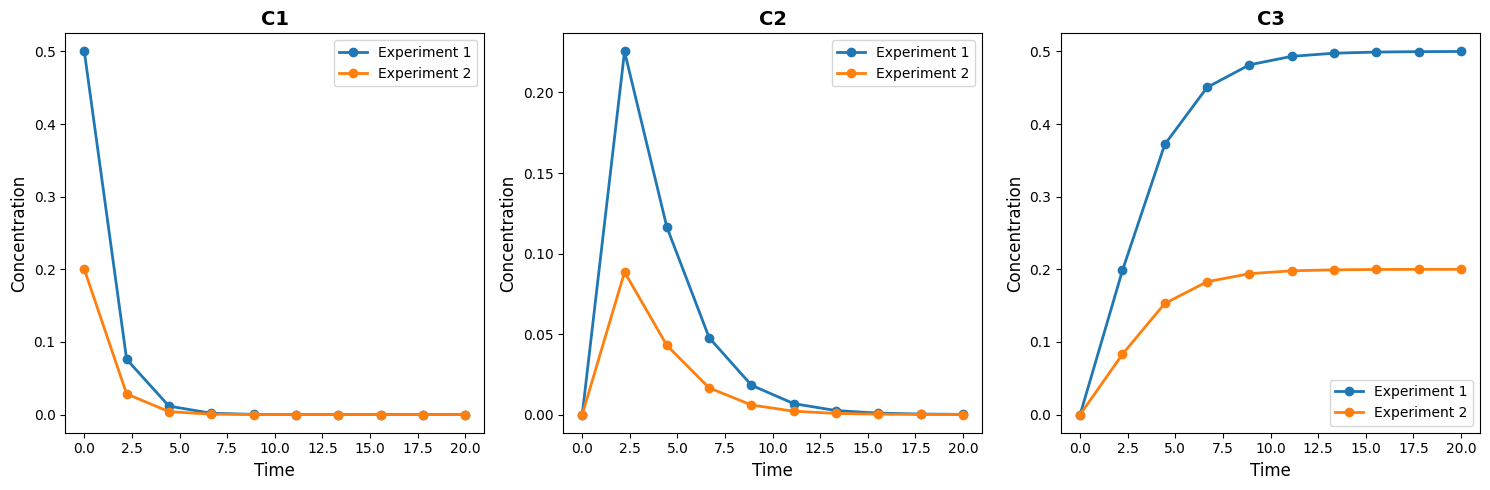

In [6]:
fig, axs = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = False)
ax = axs.ravel()

full_dict = syn_GT_no_noise(10, Ki)
keys = list(full_dict.keys())

for i in range(len(keys)):
    
    t = full_dict[keys[i]][0]
    y = full_dict[keys[i]][1]
    
    titles = []
    for j in range(len(y)):
        ax[j].plot(t, y[j], "-o", linewidth = 2, label = keys[i])
        ax[j].set_xlabel("Time", fontsize = 12)
        ax[j].set_ylabel("Concentration", fontsize = 12)
        ax[j].legend()
        ax[j].set_title("C"+str(j+1), fontweight = "bold", fontsize = 14)

plt.tight_layout()

### Generate Raman process data

In [7]:
def syn_Raman_no_noise(num_time_steps = 10, Ki = Ki, id_of_LD = [1], w_of_LD = [0.1], RSeed_STchoice = 24):
    
    id_of_LD = np.array(id_of_LD)
    w_of_LD = np.array(w_of_LD)
    concentration_dict = syn_GT_no_noise(num_time_steps, Ki)
    keys = list(concentration_dict.keys())
    
    final_dict = {}
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # Randomly Choose Raman Spectra from the BR library
    
    num_choose = len(concentration_dict[keys[0]][-1])
    
    filename_spectra = "new_biological_relevant_spectra.pkl"
    with open(filename_spectra, "rb") as file:
        spectra_pure_profile = pickle.load(file)
    keys_spc = list(spectra_pure_profile.keys())

    random.seed(RSeed_STchoice)
    select_spectra = random.sample(range(len(keys_spc)), num_choose)
    
    St = []
    wv_meas = spectra_pure_profile[keys_spc[0]][0][::12]
    
    for i in range(num_choose):
        St.append(spectra_pure_profile[keys_spc[select_spectra[i]]][1][::12])
        assert(np.all(wv_meas == spectra_pure_profile[keys_spc[select_spectra[i]]][0][::12]))
    
    St_full = np.array(St)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # Randomly Choose Raman Spectra from the BR library
    
    for i in range(len(keys)):
        
        t = concentration_dict[keys[i]][0]
        
        y_full = concentration_dict[keys[i]][1]
        
        St = []
        y = []
        for k in range(len(y_full)):
            y.append(y_full[k])
            if k not in id_of_LD:
                St.append(St_full[k])
            elif k in id_of_LD:
                St.append(w_of_LD[np.argmax(id_of_LD == k)]*St_full[k])
                
        y = np.array(y).T
        St = np.array(St)
        D = np.matmul(y, St)
        
        final_dict[keys[i]] = [t, wv_meas, D]
    
    return final_dict

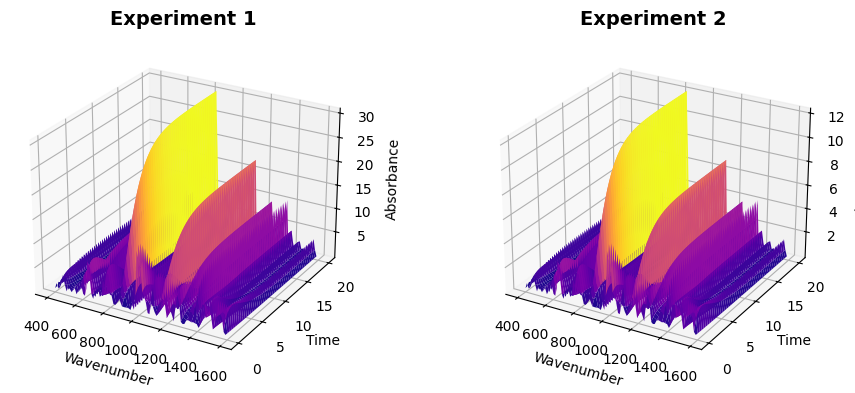

In [8]:
fig = plt.figure(figsize=(10, 4))

full_dict = syn_Raman_no_noise(1000, Ki, [1], [1], 765)
keys = list(full_dict.keys())

for i in range(len(keys)):
    
    ax = fig.add_subplot(1, len(keys), i+1, projection='3d')

    time = full_dict[keys[i]][0]
    wavenumber = full_dict[keys[i]][1]
    T, W = np.meshgrid(time, wavenumber)

    Z = full_dict[keys[i]][-1].T

    surf = ax.plot_surface(W, T, Z, cmap='plasma', edgecolor='none')
    ax.set_xlabel('Wavenumber')
    ax.set_ylabel('Time')
    ax.set_zlabel('Absorbance')
    ax.set_title(keys[i], fontweight = "bold", fontsize = 14)
    # Optional: match viewing angle across all subplots
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()

### Add multiplicative gaussian noise to Raman process data

In [9]:
def syn_Raman_noise(num_time_steps = 10, per_err = 5, Ki = Ki, id_of_LD = [1], w_of_LD = [0.1], RSeed_ST_choice = 24, RSeed_D_err = 12):
    
    Raman_dict = syn_Raman_no_noise(num_time_steps, Ki, id_of_LD, w_of_LD, RSeed_ST_choice)
    keys = list(Raman_dict.keys())
    
    full_dict = {}
    
    for i in range(len(keys)):
        
        t = Raman_dict[keys[i]][0]
        wv = Raman_dict[keys[i]][1]
        D_pure = Raman_dict[keys[i]][2]
        
        D_err = np.random.default_rng(int(RSeed_D_err + i)).standard_normal(D_pure.shape)
        D_final = D_pure * (1 + D_err*(per_err/100))
        
        full_dict[keys[i]] = [t, wv, D_final]
    
    return full_dict

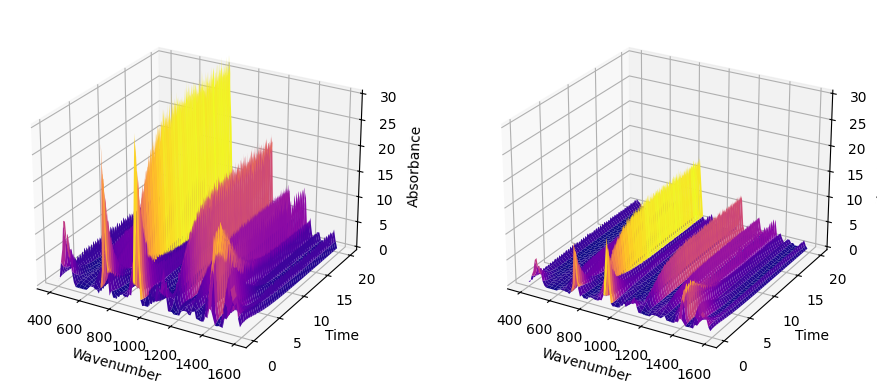

In [10]:
fig = plt.figure(figsize=(10, 4))

full_dict = syn_Raman_noise(1000, 5, Ki, [1], [1.5])
keys = list(full_dict.keys())

for i in range(len(keys)):
    
    ax = fig.add_subplot(1, len(keys), i+1, projection='3d')

    time = full_dict[keys[i]][0]
    wavenumber = full_dict[keys[i]][1]
    T, W = np.meshgrid(time, wavenumber)

    Z = full_dict[keys[i]][-1].T

    surf = ax.plot_surface(W, T, Z, cmap='plasma', edgecolor='none')
    ax.set_xlabel('Wavenumber')
    ax.set_ylabel('Time')
    ax.set_zlabel('Absorbance')
    ax.set_zlim([0, 30])
    #ax.set_title(keys[i], fontweight = "bold", fontsize = 14)
    # Optional: match viewing angle across all subplots
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()

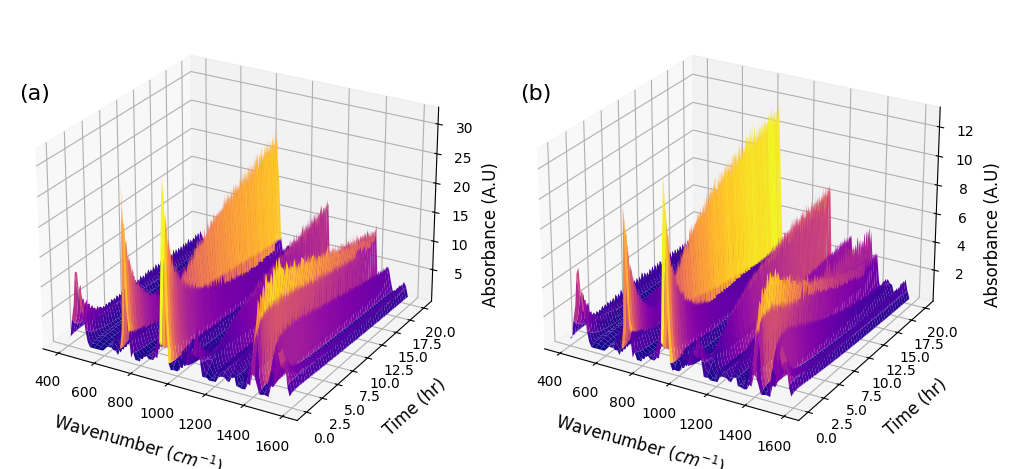

In [11]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

fig = plt.figure(figsize=(14, 5))
Ki = tuple([[0.05, 0.05]])
full_dict = syn_Raman_noise(1000, 5, Ki, [1], [1.5])
keys = list(full_dict.keys())

gs = gridspec.GridSpec(1, len(keys), wspace= -0.3)

for i in range(len(keys)):
    ax = fig.add_subplot(gs[i], projection='3d')
    time = full_dict[keys[i]][0]
    wavenumber = full_dict[keys[i]][1]
    T, W = np.meshgrid(time, wavenumber)
    Z = full_dict[keys[i]][-1].T

    surf = ax.plot_surface(W, T, Z, cmap='plasma', edgecolor='none')

    ax.set_xlabel('Wavenumber $(cm^{-1})$', labelpad=10, fontsize = 12)
    ax.set_ylabel('Time (hr)', labelpad=10, fontsize = 12)

    # Skip set_zlabel — use text2D instead so it renders on every panel
    ax.text2D(
        1.05, 0.5, 'Absorbance (A.U)',
        transform=ax.transAxes,
        fontsize=12,
        va='center',
        ha='left',
        rotation=90
    )

    ax.view_init(elev=25, azim=-60)
    #ax.set_zlim([0, 30])
    ax.set_title("")

    panel_label = f"({chr(97 + i)})"
    ax.text2D(0.02, 0.8, panel_label,
              transform=ax.transAxes,
              fontsize=16,
              fontweight='normal')

plt.subplots_adjust(
    left=0.05,
    right=0.92,
    top=0.95,
    bottom=0.05,
)
#plt.savefig("Syn_raman_data.svg", dpi = 300, bbox_inches = "tight")
#plt.show()